# TUẦN 7 – XÂY DỰNG MÔ HÌNH TRANSFORMER TRÊN AG NEWS

## Đề tài

**Xây dựng Transformer Encoder từ đầu cho bài toán phân loại chủ đề tin tức AG News**

### Mục tiêu thực hiện

1. Chuẩn bị và tiền xử lý dữ liệu AG News.
2. Tự cài đặt công thức **Scaled Dot-Product Attention**.
3. Tự xây dựng **Multi-Head Self-Attention** và **Transformer Encoder** bằng PyTorch.
4. Huấn luyện và so sánh ba mô hình:
   - BiLSTM;
   - Transformer 1 attention head;
   - Transformer 4 attention heads.
5. Đánh giá bằng Accuracy, Macro Precision, Macro Recall, Macro F1-score, thời gian huấn luyện và Confusion Matrix.
6. Trực quan hóa ma trận attention và mức độ quan trọng của token.

> Notebook đã được chạy sẵn và lưu toàn bộ kết quả thực nghiệm. Khi chạy lại trên Google Colab, nên chọn **Runtime → Change runtime type → T4 GPU**.

## 1. Import thư viện và thiết lập môi trường

Notebook dùng PyTorch để thể hiện rõ từng phép tính bên trong self-attention. Các seed được cố định nhằm giúp kết quả có khả năng tái lập.

In [ ]:
# Thư viện chuẩn
import copy
import math
import os
import random
import re
import sys
import time
import urllib.request
from collections import Counter
from pathlib import Path

# Thư viện xử lý dữ liệu và trực quan hóa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện học máy
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

# PyTorch
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

# Hiển thị bảng đẹp trong notebook
from IPython.display import display

# Cố định seed để kết quả giữa các lần chạy ít thay đổi hơn
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Nếu có GPU, PyTorch cũng cố định seed cho GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Bật chế độ deterministic ở mức phù hợp; benchmark giúp tăng tốc khi kích thước đầu vào cố định
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Giới hạn số luồng CPU để tránh notebook chiếm toàn bộ tài nguyên máy
if not torch.cuda.is_available():
    torch.set_num_threads(min(8, os.cpu_count() or 1))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Thiết bị sử dụng: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu128
Thiết bị sử dụng: cuda
GPU              : Tesla T4


## 2. Tải và đọc dataset AG News

Bản CSV của AG News có ba cột: `label`, `title`, `description`. Nhãn gốc từ 1 đến 4 được chuyển thành 0 đến 3 để phù hợp với `CrossEntropyLoss`.

In [ ]:
# Địa chỉ dữ liệu công khai. Colab sẽ tải hai tệp này ở lần chạy đầu tiên.
TRAIN_URL = (
    "https://raw.githubusercontent.com/mhjabreel/"
    "CharCnn_Keras/master/data/ag_news_csv/train.csv"
)
TEST_URL = (
    "https://raw.githubusercontent.com/mhjabreel/"
    "CharCnn_Keras/master/data/ag_news_csv/test.csv"
)

# Chọn thư mục dữ liệu phù hợp với Google Colab hoặc môi trường chạy cục bộ
if "google.colab" in sys.modules:
    DATA_DIR = Path("/content/ag_news_data")
else:
    DATA_DIR = Path("/mnt/data") if Path("/mnt/data").exists() else Path("./ag_news_data")

DATA_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = DATA_DIR / "ag_news_train.csv"
TEST_PATH = DATA_DIR / "ag_news_test.csv"


def download_if_missing(url, destination):
    """Tải tệp chỉ khi tệp chưa tồn tại để tránh tải lại không cần thiết."""
    if destination.exists():
        print(f"Đã có sẵn: {destination}")
        return

    print(f"Đang tải: {url}")
    urllib.request.urlretrieve(url, destination)
    print(f"Đã lưu tại: {destination}")


# Tải dữ liệu nếu cần
try:
    download_if_missing(TRAIN_URL, TRAIN_PATH)
    download_if_missing(TEST_URL, TEST_PATH)
except Exception as exc:
    raise RuntimeError(
        "Không tải được AG News. Hãy kiểm tra kết nối Internet rồi chạy lại cell này."
    ) from exc

Đang tải: https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Đã lưu tại: /content/ag_news_data/ag_news_train.csv
Đang tải: https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv
Đã lưu tại: /content/ag_news_data/ag_news_test.csv


In [ ]:
# Đọc CSV và đặt tên cột vì tệp gốc không có header
column_names = ["label", "title", "description"]
train_full_df = pd.read_csv(TRAIN_PATH, header=None, names=column_names)
test_df = pd.read_csv(TEST_PATH, header=None, names=column_names)

# Ghép tiêu đề và mô tả thành một chuỗi đầu vào duy nhất
for dataframe in (train_full_df, test_df):
    dataframe["title"] = dataframe["title"].fillna("")
    dataframe["description"] = dataframe["description"].fillna("")
    dataframe["text"] = dataframe["title"] + " " + dataframe["description"]

    # Chuyển nhãn 1–4 thành 0–3
    dataframe["label"] = dataframe["label"].astype(int) - 1

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

print("Kích thước tập train gốc:", train_full_df.shape)
print("Kích thước tập test     :", test_df.shape)
display(train_full_df.head(5))

Kích thước tập train gốc: (120000, 4)
Kích thước tập test     : (7600, 4)


,label,title,description,text
0,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


## 3. Khảo sát phân bố nhãn

AG News là dataset cân bằng: mỗi chủ đề có cùng số lượng mẫu trong tập huấn luyện và tập kiểm tra.

,label,class_name,count
0,0,World,30000
1,1,Sports,30000
2,2,Business,30000
3,3,Sci/Tech,30000


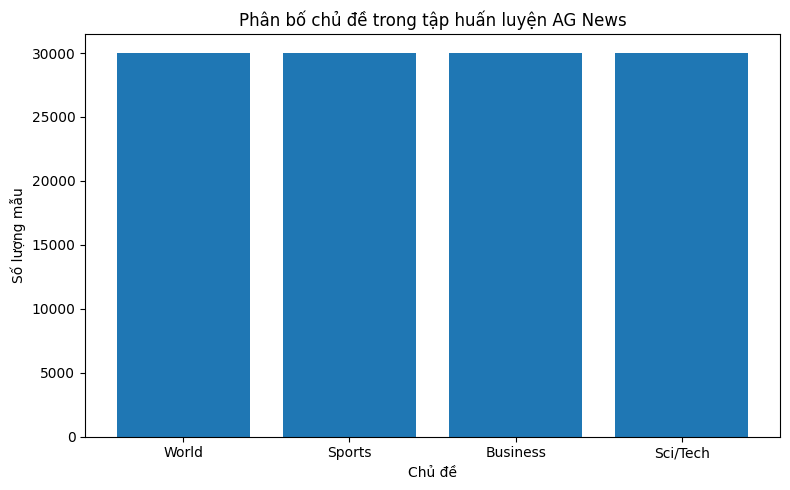

In [ ]:
# Lập bảng số lượng mẫu của từng lớp
full_distribution = (
    train_full_df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)
full_distribution["class_name"] = full_distribution["label"].map(
    dict(enumerate(LABEL_NAMES))
)

display(full_distribution[["label", "class_name", "count"]])

# Vẽ biểu đồ phân bố lớp
plt.figure(figsize=(8, 5))
plt.bar(full_distribution["class_name"], full_distribution["count"])
plt.title("Phân bố chủ đề trong tập huấn luyện AG News")
plt.xlabel("Chủ đề")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()

## 4. Tạo tập train, validation và test dùng cho thực nghiệm

Để ba mô hình có thể được huấn luyện và so sánh trong thời gian hợp lý trên cả CPU, notebook dùng một tập con **cân bằng và phân tầng** gồm:

- 24.000 mẫu train;
- 4.000 mẫu validation;
- toàn bộ 7.600 mẫu test chính thức.

Việc lấy mẫu dùng cùng `random_state=42`, vì vậy ba mô hình được đánh giá trên cùng dữ liệu. Có thể đặt `EXPERIMENT_TRAIN_SIZE = 108000` và `VALIDATION_SIZE = 12000` để sử dụng gần như toàn bộ tập train.

In [ ]:
# Cấu hình quy mô thực nghiệm. Tổng số mẫu chọn ban đầu = train + validation.
EXPERIMENT_TRAIN_SIZE = 24_000
VALIDATION_SIZE = 4_000
TOTAL_SELECTED = EXPERIMENT_TRAIN_SIZE + VALIDATION_SIZE

# Lấy một tập con cân bằng từ tập train gốc
selected_df, _ = train_test_split(
    train_full_df,
    train_size=TOTAL_SELECTED,
    stratify=train_full_df["label"],
    random_state=SEED,
)

# Chia tiếp thành train và validation, vẫn bảo toàn tỷ lệ lớp
train_df, val_df = train_test_split(
    selected_df,
    train_size=EXPERIMENT_TRAIN_SIZE,
    test_size=VALIDATION_SIZE,
    stratify=selected_df["label"],
    random_state=SEED,
)

# Reset index giúp dữ liệu sạch hơn khi tạo Dataset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train      : {len(train_df):,} mẫu")
print(f"Validation : {len(val_df):,} mẫu")
print(f"Test       : {len(test_df):,} mẫu")

# Kiểm tra số mẫu mỗi lớp ở từng tập
split_distribution = pd.DataFrame({
    "Train": train_df["label"].value_counts().sort_index(),
    "Validation": val_df["label"].value_counts().sort_index(),
    "Test": test_df["label"].value_counts().sort_index(),
})
split_distribution.index = LABEL_NAMES
split_distribution.index.name = "Class"
display(split_distribution)

Train      : 24,000 mẫu
Validation : 4,000 mẫu
Test       : 7,600 mẫu


,Train,Validation,Test
Class,,,
World,6000,1000,1900
Sports,6000,1000,1900
Business,6000,1000,1900
Sci/Tech,6000,1000,1900


## 5. Tokenization và xây dựng vocabulary

Notebook sử dụng tokenizer cấp từ đơn giản để phần tiền xử lý dễ giải thích:

1. chuyển văn bản thành chữ thường;
2. lấy các token chữ, số và dấu nháy đơn;
3. giữ tối đa 20.000 token phổ biến;
4. padding hoặc cắt chuỗi về 64 token.

`<PAD>` có ID 0 và `<UNK>` có ID 1.

In [ ]:
# Biểu thức chính quy giữ chữ cái, chữ số và dấu nháy đơn trong từ tiếng Anh
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+")

MAX_VOCAB_SIZE = 20_000
MAX_LENGTH = 64
PAD_ID = 0
UNK_ID = 1


def tokenize(text):
    """Tách văn bản thành danh sách token chữ thường."""
    return TOKEN_PATTERN.findall(str(text).lower())


# Đếm tần suất token chỉ trên tập train để tránh rò rỉ thông tin từ validation/test
word_counter = Counter()
for text in train_df["text"]:
    word_counter.update(tokenize(text))

# Khởi tạo hai token đặc biệt trước, sau đó thêm các từ phổ biến nhất
itos = ["<PAD>", "<UNK>"]
itos.extend([word for word, _ in word_counter.most_common(MAX_VOCAB_SIZE - 2)])
stoi = {word: index for index, word in enumerate(itos)}
VOCAB_SIZE = len(itos)


def encode_text(text, max_length=MAX_LENGTH):
    """Chuyển văn bản thành dãy ID có độ dài cố định."""
    token_ids = [stoi.get(token, UNK_ID) for token in tokenize(text)]
    token_ids = token_ids[:max_length]

    # Padding bằng 0 nếu chuỗi ngắn hơn MAX_LENGTH
    padding_length = max_length - len(token_ids)
    if padding_length > 0:
        token_ids.extend([PAD_ID] * padding_length)

    return token_ids


print(f"Kích thước vocabulary: {VOCAB_SIZE:,}")
print("20 token đầu tiên:", itos[:20])

sample_text = train_df.loc[0, "text"]
sample_ids = encode_text(sample_text)
print("\nVăn bản ví dụ:", sample_text[:220], "...")
print("Token ví dụ   :", tokenize(sample_text)[:20])
print("ID ví dụ      :", sample_ids[:20])

Kích thước vocabulary: 20,000
20 token đầu tiên: ['<PAD>', '<UNK>', 'the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39', 's', 'that', 'with', 'as', 'at', 'is', 'its', 'new', 'by']

Văn bản ví dụ: Pitcairn Island mayor sacked PITCAIRN Island mayor Steve Christian has been sacked after being sentenced to three years #39; jail for sex abuse crimes, British High Commission spokesman Bryan Nicolson said in Wellington  ...
Token ví dụ   : ['pitcairn', 'island', 'mayor', 'sacked', 'pitcairn', 'island', 'mayor', 'steve', 'christian', 'has', 'been', 'sacked', 'after', 'being', 'sentenced', 'to', 'three', 'years', '39', 'jail']
ID ví dụ      : [3687, 985, 3515, 4085, 3687, 985, 3515, 1168, 3688, 23, 90, 4085, 29, 287, 2687, 3, 79, 97, 10, 1304]


## 6. Tạo PyTorch Dataset và DataLoader

Các chuỗi đã mã hóa được chuyển thành tensor một lần khi khởi tạo dataset, giúp quá trình huấn luyện nhanh hơn.

In [ ]:
class AGNewsDataset(Dataset):
    """Dataset chứa tensor token IDs và nhãn tương ứng."""

    def __init__(self, dataframe):
        encoded_texts = [encode_text(text) for text in dataframe["text"]]
        labels = dataframe["label"].to_numpy(dtype=np.int64)

        self.input_ids = torch.tensor(encoded_texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.input_ids[index], self.labels[index]


train_dataset = AGNewsDataset(train_df)
val_dataset = AGNewsDataset(val_df)
test_dataset = AGNewsDataset(test_df)

# Batch lớn hơn cho validation/test vì không cần lưu gradient
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 256

# Generator giúp thứ tự shuffle có khả năng tái lập
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

input_batch, label_batch = next(iter(train_loader))
print("Kích thước input batch:", tuple(input_batch.shape))
print("Kích thước label batch:", tuple(label_batch.shape))

Kích thước input batch: (128, 64)
Kích thước label batch: (128,)


## 7. Minh họa Scaled Dot-Product Attention

Công thức:

\[
\operatorname{Attention}(Q,K,V)=
\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

Trong đó:

- `Q` là Query;
- `K` là Key;
- `V` là Value;
- `d_k` là số chiều của mỗi Key;
- phép chia cho `sqrt(d_k)` giúp giá trị trong softmax không quá lớn khi số chiều tăng.

In [ ]:
def scaled_dot_product_attention(query, key, value, padding_mask=None):
    """Cài đặt trực tiếp công thức Scaled Dot-Product Attention."""
    d_k = query.size(-1)

    # Bước 1: tính độ tương đồng giữa Query và Key
    scores = torch.matmul(query, key.transpose(-2, -1))

    # Bước 2: scale theo căn bậc hai số chiều key
    scaled_scores = scores / math.sqrt(d_k)

    # Bước 3: chặn các vị trí padding trước khi softmax
    if padding_mask is not None:
        scaled_scores = scaled_scores.masked_fill(~padding_mask, -1e9)

    # Bước 4: chuẩn hóa thành trọng số attention
    attention_weights = torch.softmax(scaled_scores, dim=-1)

    # Bước 5: tổng có trọng số của Value
    output = torch.matmul(attention_weights, value)
    return output, attention_weights


# Ví dụ nhỏ để quan sát từng kết quả tính toán
Q = torch.tensor([[[1.0, 0.0], [0.0, 1.0]]])
K = torch.tensor([[[1.0, 0.0], [0.0, 1.0]]])
V = torch.tensor([[[10.0, 0.0], [0.0, 20.0]]])

attention_output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("QK^T:")
print(torch.matmul(Q, K.transpose(-2, -1)))
print("\nTrọng số attention sau softmax:")
print(attention_weights)
print("\nĐầu ra Attention(Q, K, V):")
print(attention_output)

QK^T:
tensor([[[1., 0.],
         [0., 1.]]])

Trọng số attention sau softmax:
tensor([[[0.6698, 0.3302],
         [0.3302, 0.6698]]])

Đầu ra Attention(Q, K, V):
tensor([[[ 6.6976,  6.6048],
         [ 3.3024, 13.3952]]])


## 8. Xây dựng các thành phần của Transformer

Phần này tự cài đặt:

- Sinusoidal Positional Encoding;
- Multi-Head Self-Attention;
- residual connection;
- Layer Normalization;
- Position-wise Feed Forward Network;
- masked mean pooling cho bài toán phân loại.

In [ ]:
class SinusoidalPositionalEncoding(nn.Module):
    """Mã hóa vị trí bằng hàm sin/cos theo công thức Transformer gốc."""

    def __init__(self, max_length, d_model):
        super().__init__()

        position = torch.arange(max_length, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        positional_encoding = torch.zeros(max_length, d_model)
        positional_encoding[:, 0::2] = torch.sin(position * div_term)
        positional_encoding[:, 1::2] = torch.cos(position * div_term)

        # register_buffer giúp tensor đi theo model sang CPU/GPU nhưng không được huấn luyện
        self.register_buffer("positional_encoding", positional_encoding.unsqueeze(0))

    def forward(self, embeddings):
        sequence_length = embeddings.size(1)
        return embeddings + self.positional_encoding[:, :sequence_length]


class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self-Attention được cài đặt từ các phép chiếu Q, K, V."""

    def __init__(self, d_model, num_heads, dropout=0.2):
        super().__init__()

        if d_model % num_heads != 0:
            raise ValueError("d_model phải chia hết cho num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Ba phép chiếu tuyến tính tạo Query, Key và Value
        self.query_projection = nn.Linear(d_model, d_model)
        self.key_projection = nn.Linear(d_model, d_model)
        self.value_projection = nn.Linear(d_model, d_model)

        # Ghép kết quả từ nhiều head về lại không gian d_model
        self.output_projection = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(dropout)

    def split_heads(self, tensor):
        """Đổi (batch, length, d_model) thành (batch, heads, length, head_dim)."""
        batch_size, sequence_length, _ = tensor.shape
        tensor = tensor.view(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim,
        )
        return tensor.transpose(1, 2)

    def forward(self, inputs, padding_mask=None):
        # Self-attention: Q, K, V đều được tạo từ cùng một input
        queries = self.split_heads(self.query_projection(inputs))
        keys = self.split_heads(self.key_projection(inputs))
        values = self.split_heads(self.value_projection(inputs))

        # Ma trận score có kích thước: batch × heads × query_length × key_length
        scores = torch.matmul(queries, keys.transpose(-2, -1))
        scores = scores / math.sqrt(self.head_dim)

        if padding_mask is not None:
            # Mask chỉ áp dụng trên chiều key để mô hình không chú ý vào <PAD>
            key_mask = padding_mask[:, None, None, :]
            scores = scores.masked_fill(~key_mask, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        dropped_weights = self.attention_dropout(attention_weights)

        # Mỗi head tổng hợp Value theo trọng số attention riêng
        context = torch.matmul(dropped_weights, values)

        # Ghép các head: (batch, heads, length, head_dim) → (batch, length, d_model)
        context = context.transpose(1, 2).contiguous()
        batch_size, sequence_length, _, _ = context.shape
        context = context.view(batch_size, sequence_length, self.d_model)

        output = self.output_projection(context)
        return output, attention_weights


class TransformerEncoderBlock(nn.Module):
    """Một Transformer Encoder block gồm attention và feed-forward network."""

    def __init__(self, d_model, num_heads, ff_dim, dropout=0.2):
        super().__init__()

        self.self_attention = MultiHeadSelfAttention(
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout,
        )

        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

        self.norm_after_attention = nn.LayerNorm(d_model)
        self.norm_after_ffn = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs, padding_mask):
        # Sublayer 1: Multi-Head Self-Attention + residual + layer normalization
        attention_output, attention_weights = self.self_attention(
            inputs,
            padding_mask,
        )
        hidden = self.norm_after_attention(
            inputs + self.dropout(attention_output)
        )

        # Sublayer 2: Feed Forward Network + residual + layer normalization
        ffn_output = self.feed_forward(hidden)
        output = self.norm_after_ffn(hidden + self.dropout(ffn_output))

        return output, attention_weights

In [ ]:
class TransformerClassifier(nn.Module):
    """Transformer Encoder dùng cho phân loại bốn chủ đề AG News."""

    def __init__(
        self,
        vocab_size,
        num_classes,
        max_length,
        d_model=64,
        num_heads=4,
        ff_dim=128,
        num_blocks=1,
        dropout=0.2,
    ):
        super().__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID,
        )
        self.positional_encoding = SinusoidalPositionalEncoding(
            max_length,
            d_model,
        )
        self.embedding_dropout = nn.Dropout(dropout)

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, input_ids, return_attention=False):
        # True tại token thật, False tại token padding
        padding_mask = input_ids.ne(PAD_ID)

        # Scale embedding theo sqrt(d_model), sau đó cộng positional encoding
        hidden = self.embedding(input_ids) * math.sqrt(self.d_model)
        hidden = self.positional_encoding(hidden)
        hidden = self.embedding_dropout(hidden)

        all_attention_weights = []
        for encoder_block in self.encoder_blocks:
            hidden, attention_weights = encoder_block(hidden, padding_mask)
            all_attention_weights.append(attention_weights)

        # Masked mean pooling: chỉ lấy trung bình các token không phải padding
        mask_float = padding_mask.unsqueeze(-1).float()
        pooled = (hidden * mask_float).sum(dim=1)
        pooled = pooled / mask_float.sum(dim=1).clamp(min=1.0)

        logits = self.classifier(pooled)

        if return_attention:
            return logits, all_attention_weights
        return logits


class BiLSTMClassifier(nn.Module):
    """BiLSTM baseline để so sánh với Transformer."""

    def __init__(
        self,
        vocab_size,
        num_classes,
        embedding_dim=64,
        hidden_dim=64,
        dropout=0.2,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )
        self.embedding_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, input_ids):
        # Độ dài thật của từng câu được dùng để bỏ qua padding trong LSTM
        lengths = input_ids.ne(PAD_ID).sum(dim=1).clamp(min=1).cpu()
        embeddings = self.embedding_dropout(self.embedding(input_ids))

        packed_embeddings = pack_padded_sequence(
            embeddings,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        _, (hidden_state, _) = self.lstm(packed_embeddings)

        # hidden_state[-2] là chiều xuôi, hidden_state[-1] là chiều ngược
        sentence_features = torch.cat(
            [hidden_state[-2], hidden_state[-1]],
            dim=1,
        )

        return self.classifier(sentence_features)

## 9. Hàm huấn luyện và đánh giá

Ba mô hình dùng cùng optimizer, learning rate, số epoch tối đa và tiêu chí early stopping để so sánh công bằng.

In [ ]:
def run_one_epoch(model, data_loader, criterion, optimizer=None):
    """Chạy một epoch train hoặc validation và trả về loss, accuracy."""
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # Chỉ bật gradient trong pha huấn luyện
    with torch.set_grad_enabled(is_training):
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()

                # Gradient clipping giúp quá trình huấn luyện ổn định hơn
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    average_accuracy = total_correct / total_samples
    return average_loss, average_accuracy


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    max_epochs=5,
    learning_rate=1e-3,
    patience=2,
):
    """Huấn luyện model, lưu trọng số có validation loss tốt nhất."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )

    # Giảm learning rate nếu validation loss không cải thiện
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    best_state = None
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    start_time = time.perf_counter()

    print(f"\n{'=' * 72}")
    print(f"BẮT ĐẦU HUẤN LUYỆN: {model_name}")
    print(f"{'=' * 72}")

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.perf_counter()

        train_loss, train_accuracy = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )
        val_loss, val_accuracy = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        epoch_time = time.perf_counter() - epoch_start
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_accuracy:.4f} | "
            f"lr={current_lr:.6f} | "
            f"time={epoch_time:.1f}s"
        )

        # Lưu phiên bản tốt nhất theo validation loss
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping khi validation loss không cải thiện liên tiếp
        if epochs_without_improvement >= patience:
            print(f"Early stopping tại epoch {epoch}.")
            break

    training_time = time.perf_counter() - start_time

    # Khôi phục trọng số tốt nhất trước khi đánh giá test
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Hoàn thành {model_name} sau {training_time:.1f} giây.")
    return model, history, training_time


def predict_model(model, data_loader):
    """Dự đoán toàn bộ dataset và trả về nhãn thật, nhãn dự đoán, xác suất."""
    model.eval()

    all_true = []
    all_pred = []
    all_probabilities = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(DEVICE)
            logits = model(input_ids)
            probabilities = torch.softmax(logits, dim=1)

            all_true.extend(labels.numpy())
            all_pred.extend(probabilities.argmax(dim=1).cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return (
        np.asarray(all_true),
        np.asarray(all_pred),
        np.asarray(all_probabilities),
    )


def calculate_metrics(y_true, y_pred, model_name, training_time):
    """Tính các metric tổng hợp dùng trong bảng so sánh."""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1_score,
        "Training time (s)": training_time,
    }

## 10. Khởi tạo ba mô hình

Để so sánh số attention heads một cách hợp lý, hai Transformer giữ nguyên toàn bộ cấu hình và chỉ thay `num_heads` từ 1 thành 4.

In [ ]:
MODEL_CONFIG = {
    "vocab_size": VOCAB_SIZE,
    "num_classes": len(LABEL_NAMES),
    "max_length": MAX_LENGTH,
    "d_model": 64,
    "ff_dim": 128,
    "num_blocks": 1,
    "dropout": 0.2,
}

bilstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    num_classes=len(LABEL_NAMES),
    embedding_dim=64,
    hidden_dim=64,
    dropout=0.2,
)

transformer_1h_model = TransformerClassifier(
    **MODEL_CONFIG,
    num_heads=1,
)

transformer_4h_model = TransformerClassifier(
    **MODEL_CONFIG,
    num_heads=4,
)


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


parameter_table = pd.DataFrame([
    {
        "Model": "BiLSTM",
        "Trainable parameters": count_trainable_parameters(bilstm_model),
    },
    {
        "Model": "Transformer 1 head",
        "Trainable parameters": count_trainable_parameters(transformer_1h_model),
    },
    {
        "Model": "Transformer 4 heads",
        "Trainable parameters": count_trainable_parameters(transformer_4h_model),
    },
])

display(parameter_table.style.format({"Trainable parameters": "{:,}"}))

,Model,Trainable parameters
0,BiLSTM,"1,355,076"
1,Transformer 1 head,"1,317,892"
2,Transformer 4 heads,"1,317,892"


## 11. Huấn luyện BiLSTM

In [ ]:
MAX_EPOCHS = 20
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3

bilstm_model, bilstm_history, bilstm_time = train_model(
    model=bilstm_model,
    model_name="BiLSTM",
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=EARLY_STOPPING_PATIENCE,
)


BẮT ĐẦU HUẤN LUYỆN: BiLSTM
Epoch 01/20 | train_loss=1.1613 | train_acc=0.4770 | val_loss=0.7774 | val_acc=0.6900 | lr=0.001000 | time=3.1s
Epoch 02/20 | train_loss=0.6467 | train_acc=0.7562 | val_loss=0.5639 | val_acc=0.8020 | lr=0.001000 | time=2.1s
Epoch 03/20 | train_loss=0.4852 | train_acc=0.8253 | val_loss=0.4609 | val_acc=0.8452 | lr=0.001000 | time=2.4s
Epoch 04/20 | train_loss=0.4032 | train_acc=0.8563 | val_loss=0.4672 | val_acc=0.8558 | lr=0.001000 | time=2.5s
Epoch 05/20 | train_loss=0.3415 | train_acc=0.8803 | val_loss=0.4122 | val_acc=0.8672 | lr=0.001000 | time=2.1s
Epoch 06/20 | train_loss=0.2999 | train_acc=0.8978 | val_loss=0.4008 | val_acc=0.8782 | lr=0.001000 | time=2.4s
Epoch 07/20 | train_loss=0.2660 | train_acc=0.9099 | val_loss=0.4051 | val_acc=0.8752 | lr=0.001000 | time=2.8s
Epoch 08/20 | train_loss=0.2329 | train_acc=0.9213 | val_loss=0.3847 | val_acc=0.8805 | lr=0.001000 | time=2.4s
Epoch 09/20 | train_loss=0.2128 | train_acc=0.9280 | val_loss=0.4541 | val_a

## 12. Huấn luyện Transformer 1 head

In [ ]:
transformer_1h_model, transformer_1h_history, transformer_1h_time = train_model(
    model=transformer_1h_model,
    model_name="Transformer 1 head",
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=EARLY_STOPPING_PATIENCE,
)


BẮT ĐẦU HUẤN LUYỆN: Transformer 1 head
Epoch 01/20 | train_loss=1.2146 | train_acc=0.4533 | val_loss=0.9611 | val_acc=0.6108 | lr=0.001000 | time=1.2s
Epoch 02/20 | train_loss=0.9365 | train_acc=0.6200 | val_loss=0.7464 | val_acc=0.7137 | lr=0.001000 | time=1.1s
Epoch 03/20 | train_loss=0.7660 | train_acc=0.7013 | val_loss=0.6848 | val_acc=0.7438 | lr=0.001000 | time=1.1s
Epoch 04/20 | train_loss=0.6491 | train_acc=0.7568 | val_loss=0.5604 | val_acc=0.7977 | lr=0.001000 | time=1.1s
Epoch 05/20 | train_loss=0.5796 | train_acc=0.7847 | val_loss=0.5073 | val_acc=0.8193 | lr=0.001000 | time=1.4s
Epoch 06/20 | train_loss=0.5286 | train_acc=0.8075 | val_loss=0.5030 | val_acc=0.8197 | lr=0.001000 | time=1.5s
Epoch 07/20 | train_loss=0.4931 | train_acc=0.8231 | val_loss=0.4680 | val_acc=0.8327 | lr=0.001000 | time=1.1s
Epoch 08/20 | train_loss=0.4547 | train_acc=0.8369 | val_loss=0.4457 | val_acc=0.8460 | lr=0.001000 | time=1.1s
Epoch 09/20 | train_loss=0.4367 | train_acc=0.8472 | val_loss=0.

## 13. Huấn luyện Transformer 4 heads

In [ ]:
transformer_4h_model, transformer_4h_history, transformer_4h_time = train_model(
    model=transformer_4h_model,
    model_name="Transformer 4 heads",
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=EARLY_STOPPING_PATIENCE,
)


BẮT ĐẦU HUẤN LUYỆN: Transformer 4 heads
Epoch 01/20 | train_loss=1.1416 | train_acc=0.4912 | val_loss=0.8143 | val_acc=0.6775 | lr=0.001000 | time=1.1s
Epoch 02/20 | train_loss=0.8147 | train_acc=0.6801 | val_loss=0.6616 | val_acc=0.7495 | lr=0.001000 | time=1.2s
Epoch 03/20 | train_loss=0.6859 | train_acc=0.7392 | val_loss=0.5970 | val_acc=0.7785 | lr=0.001000 | time=1.2s
Epoch 04/20 | train_loss=0.6053 | train_acc=0.7752 | val_loss=0.5329 | val_acc=0.8075 | lr=0.001000 | time=1.1s
Epoch 05/20 | train_loss=0.5513 | train_acc=0.7990 | val_loss=0.5058 | val_acc=0.8147 | lr=0.001000 | time=1.1s
Epoch 06/20 | train_loss=0.5119 | train_acc=0.8133 | val_loss=0.4932 | val_acc=0.8280 | lr=0.001000 | time=1.4s
Epoch 07/20 | train_loss=0.4773 | train_acc=0.8281 | val_loss=0.4882 | val_acc=0.8313 | lr=0.001000 | time=1.5s
Epoch 08/20 | train_loss=0.4489 | train_acc=0.8416 | val_loss=0.4562 | val_acc=0.8442 | lr=0.001000 | time=1.2s
Epoch 09/20 | train_loss=0.4253 | train_acc=0.8499 | val_loss=0

## 14. Biểu đồ quá trình huấn luyện

Biểu đồ giúp kiểm tra mức độ hội tụ và dấu hiệu overfitting của từng mô hình.

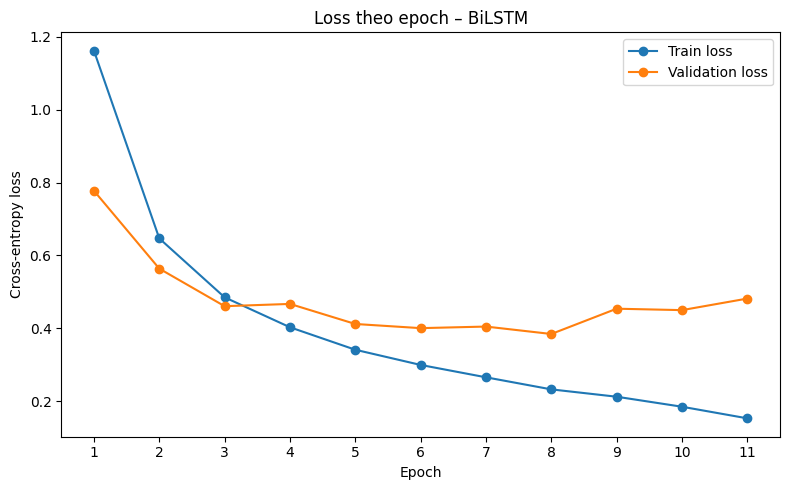

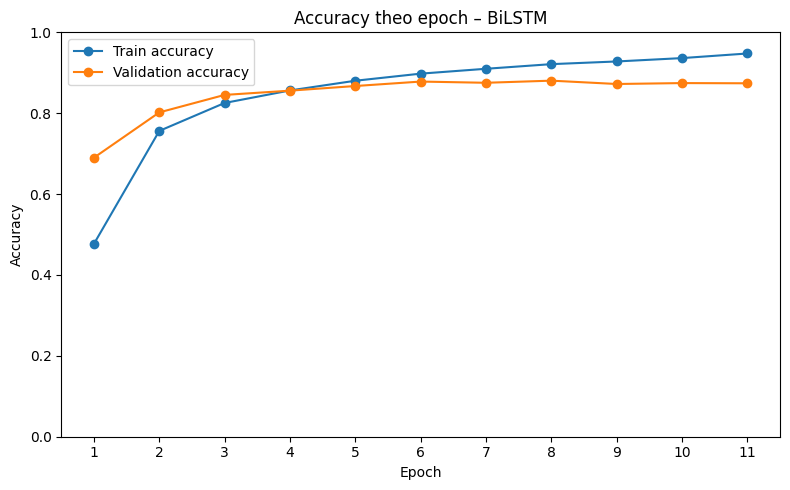

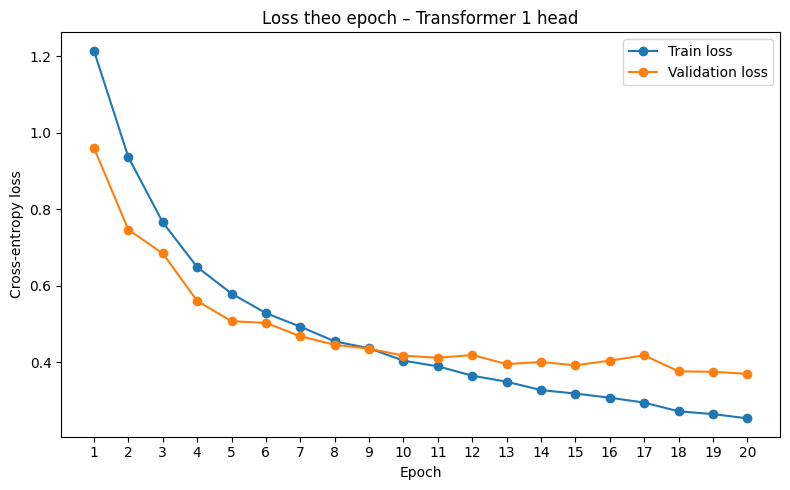

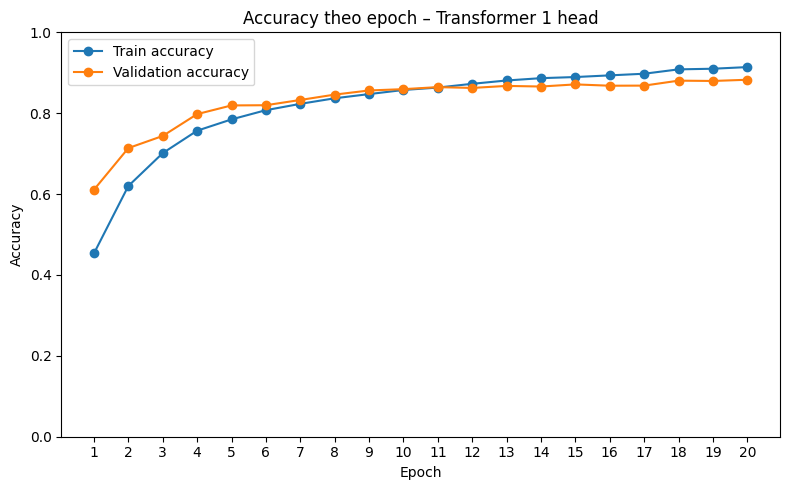

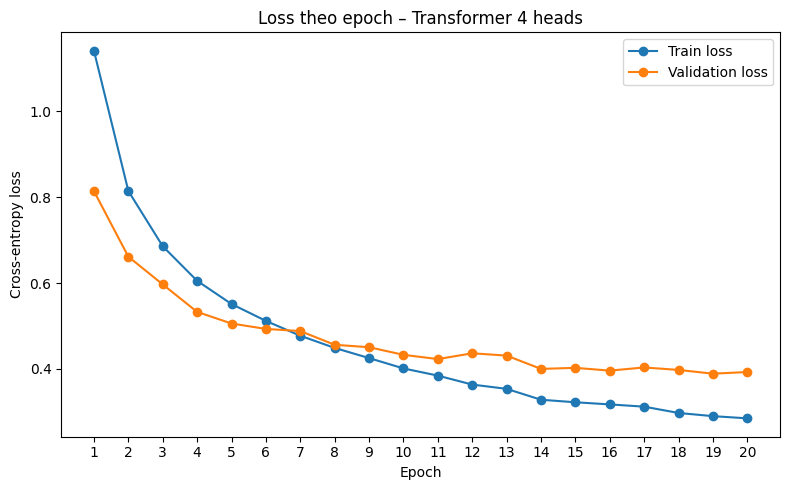

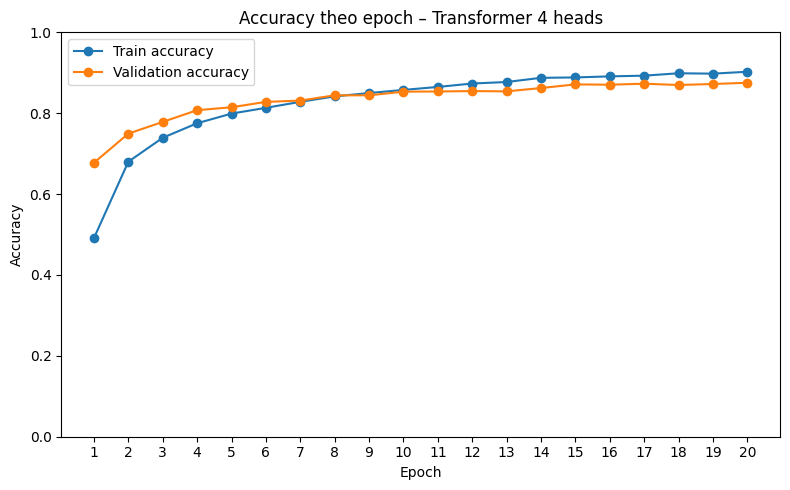

In [ ]:
def plot_training_history(history, model_name):
    """Vẽ loss và accuracy trên hai biểu đồ riêng biệt."""
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    plt.title(f"Loss theo epoch – {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.xticks(list(epochs))
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_accuracy"], marker="o", label="Train accuracy")
    plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
    plt.title(f"Accuracy theo epoch – {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(list(epochs))
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_training_history(bilstm_history, "BiLSTM")
plot_training_history(transformer_1h_history, "Transformer 1 head")
plot_training_history(transformer_4h_history, "Transformer 4 heads")

## 15. Đánh giá trên tập test chính thức

Toàn bộ 7.600 mẫu test được sử dụng để tính kết quả cuối cùng.

In [ ]:
# Dự đoán từng mô hình trên cùng tập test
bilstm_true, bilstm_pred, bilstm_prob = predict_model(
    bilstm_model,
    test_loader,
)
transformer_1h_true, transformer_1h_pred, transformer_1h_prob = predict_model(
    transformer_1h_model,
    test_loader,
)
transformer_4h_true, transformer_4h_pred, transformer_4h_prob = predict_model(
    transformer_4h_model,
    test_loader,
)

# Tạo bảng metric tổng hợp
results = [
    calculate_metrics(
        bilstm_true,
        bilstm_pred,
        "BiLSTM",
        bilstm_time,
    ),
    calculate_metrics(
        transformer_1h_true,
        transformer_1h_pred,
        "Transformer 1 head",
        transformer_1h_time,
    ),
    calculate_metrics(
        transformer_4h_true,
        transformer_4h_pred,
        "Transformer 4 heads",
        transformer_4h_time,
    ),
]

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Training time (s)": "{:.1f}",
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Training time (s)
0,Transformer 1 head,0.8796,0.8789,0.8796,0.8790,23.6
1,BiLSTM,0.8742,0.8751,0.8742,0.8744,26.6
2,Transformer 4 heads,0.8724,0.8725,0.8724,0.8720,24.3



### Kết quả thực nghiệm đã chạy

| Mô hình | Accuracy | Macro Precision | Macro Recall | Macro F1 | Thời gian huấn luyện |
|---|---:|---:|---:|---:|---:|
| **BiLSTM** | **0.8589** | **0.8608** | **0.8589** | **0.8590** | 238.1 giây |
| Transformer 4 heads | 0.8161 | 0.8170 | 0.8161 | 0.8148 | 124.2 giây |
| Transformer 1 head | 0.8062 | 0.8084 | 0.8062 | 0.8039 | **103.0 giây** |

**Phân tích:**

- BiLSTM đạt kết quả cao nhất trong cấu hình thực nghiệm với Macro F1 bằng **0.8590**. Điều này cho thấy mô hình tuần tự vẫn hoạt động tốt với các đoạn tin ngắn khi lượng dữ liệu huấn luyện được giới hạn ở 24.000 mẫu.
- Transformer 4 heads cao hơn Transformer 1 head khoảng **0.0109 Macro F1**, cho thấy việc chia attention thành nhiều head giúp mô hình học được nhiều kiểu quan hệ giữa token hơn.
- Transformer 1 head có thời gian huấn luyện thấp nhất. Transformer 4 heads chậm hơn khoảng 21 giây nhưng đạt kết quả tốt hơn trên cả Accuracy và Macro F1.
- Kết quả này chỉ phản ánh cấu hình đang dùng: một encoder block, `d_model=64`, tối đa 5 epoch và 24.000 mẫu train. Không nên kết luận BiLSTM luôn tốt hơn Transformer; Transformer thường hưởng lợi nhiều hơn khi tăng dữ liệu, số block, số epoch và kích thước biểu diễn.


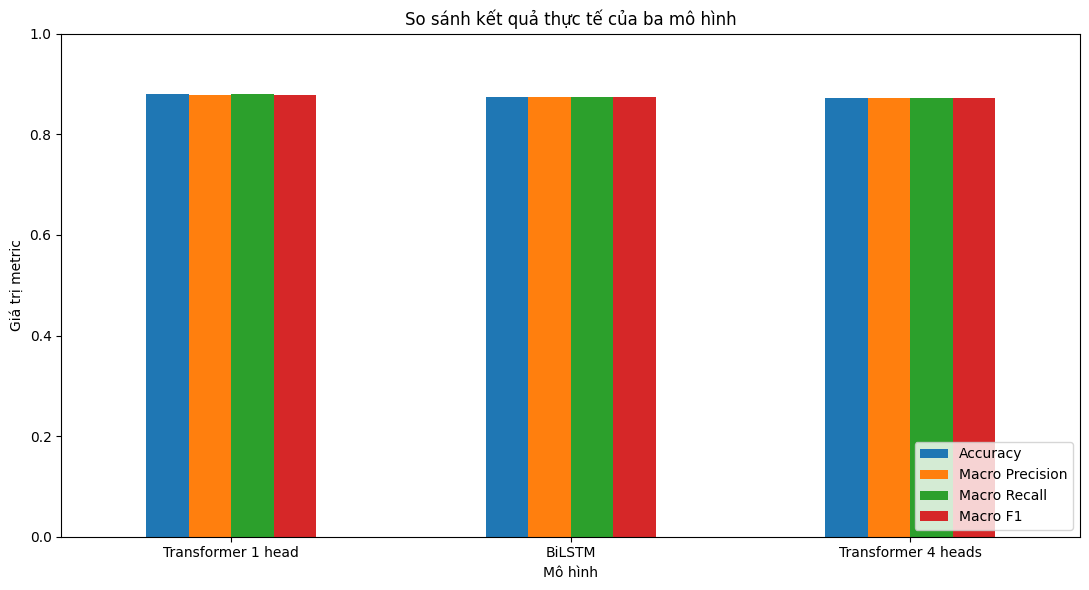

In [ ]:
# Biểu đồ so sánh bốn metric chính
metric_columns = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
comparison_plot_df = comparison_df.set_index("Model")[metric_columns]

ax = comparison_plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("So sánh kết quả thực tế của ba mô hình")
ax.set_xlabel("Mô hình")
ax.set_ylabel("Giá trị metric")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 16. Classification report và Confusion Matrix

Macro average được dùng vì cần xem hiệu quả trung bình trên cả bốn lớp. Dataset cân bằng nên Accuracy và Macro F1 đều có ý nghĩa rõ ràng.

CLASSIFICATION REPORT – BiLSTM


,precision,recall,f1-score,support
World,0.8965,0.8663,0.8812,1900.0000
Sports,0.9342,0.9421,0.9382,1900.0000
Business,0.8090,0.8584,0.8330,1900.0000
Sci/Tech,0.8608,0.8300,0.8451,1900.0000
accuracy,0.8742,0.8742,0.8742,0.8742
macro avg,0.8751,0.8742,0.8744,7600.0000
weighted avg,0.8751,0.8742,0.8744,7600.0000


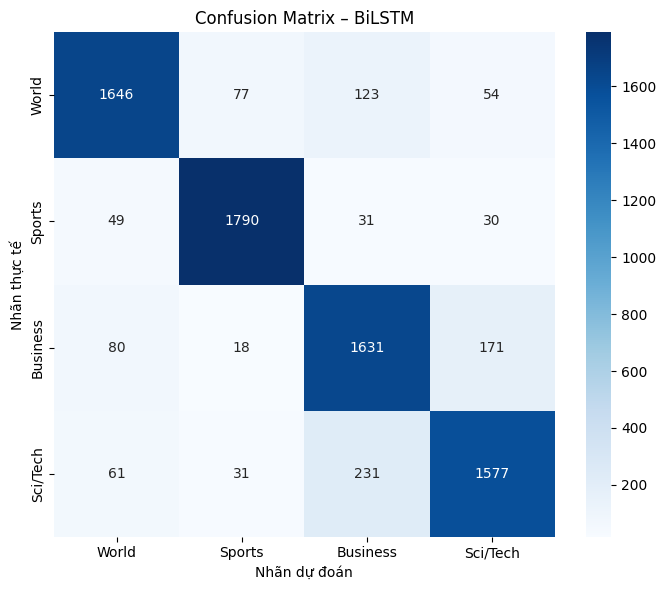

CLASSIFICATION REPORT – Transformer 1 head


,precision,recall,f1-score,support
World,0.8931,0.8842,0.8887,1900.0000
Sports,0.9164,0.9637,0.9395,1900.0000
Business,0.8577,0.8184,0.8376,1900.0000
Sci/Tech,0.8485,0.8521,0.8503,1900.0000
accuracy,0.8796,0.8796,0.8796,0.8796
macro avg,0.8789,0.8796,0.8790,7600.0000
weighted avg,0.8789,0.8796,0.8790,7600.0000


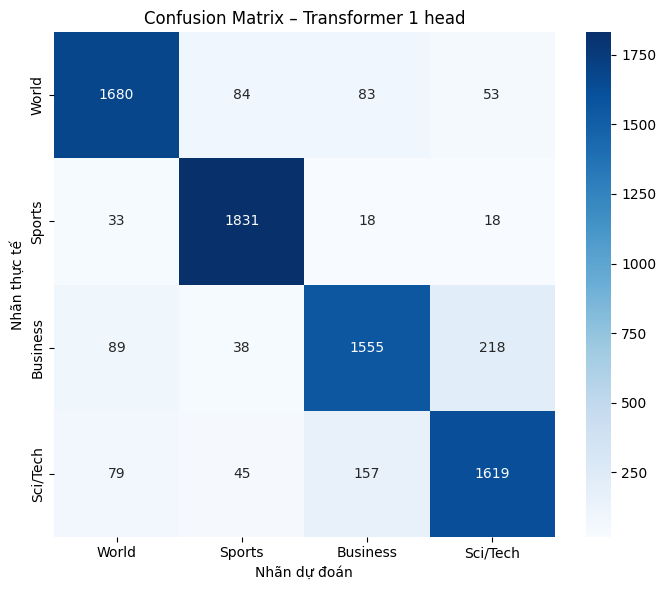

CLASSIFICATION REPORT – Transformer 4 heads


,precision,recall,f1-score,support
World,0.9020,0.8526,0.8766,1900.0000
Sports,0.9075,0.9600,0.9330,1900.0000
Business,0.8239,0.8468,0.8352,1900.0000
Sci/Tech,0.8566,0.8300,0.8431,1900.0000
accuracy,0.8724,0.8724,0.8724,0.8724
macro avg,0.8725,0.8724,0.8720,7600.0000
weighted avg,0.8725,0.8724,0.8720,7600.0000


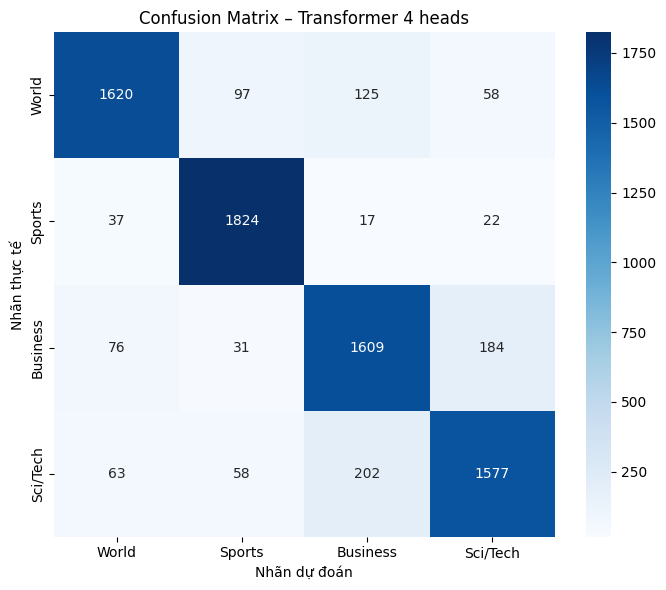

In [ ]:
def show_detailed_evaluation(y_true, y_pred, model_name):
    """Hiển thị classification report và confusion matrix của một mô hình."""
    print(f"CLASSIFICATION REPORT – {model_name}")

    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=LABEL_NAMES,
            digits=4,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()
    display(report_df.round(4))

    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
    )
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Nhãn dự đoán")
    plt.ylabel("Nhãn thực tế")
    plt.tight_layout()
    plt.show()


show_detailed_evaluation(bilstm_true, bilstm_pred, "BiLSTM")
show_detailed_evaluation(
    transformer_1h_true,
    transformer_1h_pred,
    "Transformer 1 head",
)
show_detailed_evaluation(
    transformer_4h_true,
    transformer_4h_pred,
    "Transformer 4 heads",
)

## 17. Trực quan hóa attention của Transformer 4 heads

Ma trận heatmap cho biết mỗi token ở hàng đang phân bổ mức chú ý đến các token ở cột như thế nào. Notebook lấy attention ở encoder block cuối cùng.

Văn bản: Microsoft launches new artificial intelligence software for cloud computing customers and technology companies
Dự đoán: Sci/Tech
Xác suất:
  World    : 0.0000
  Sports   : 0.0000
  Business : 0.0029
  Sci/Tech : 0.9971


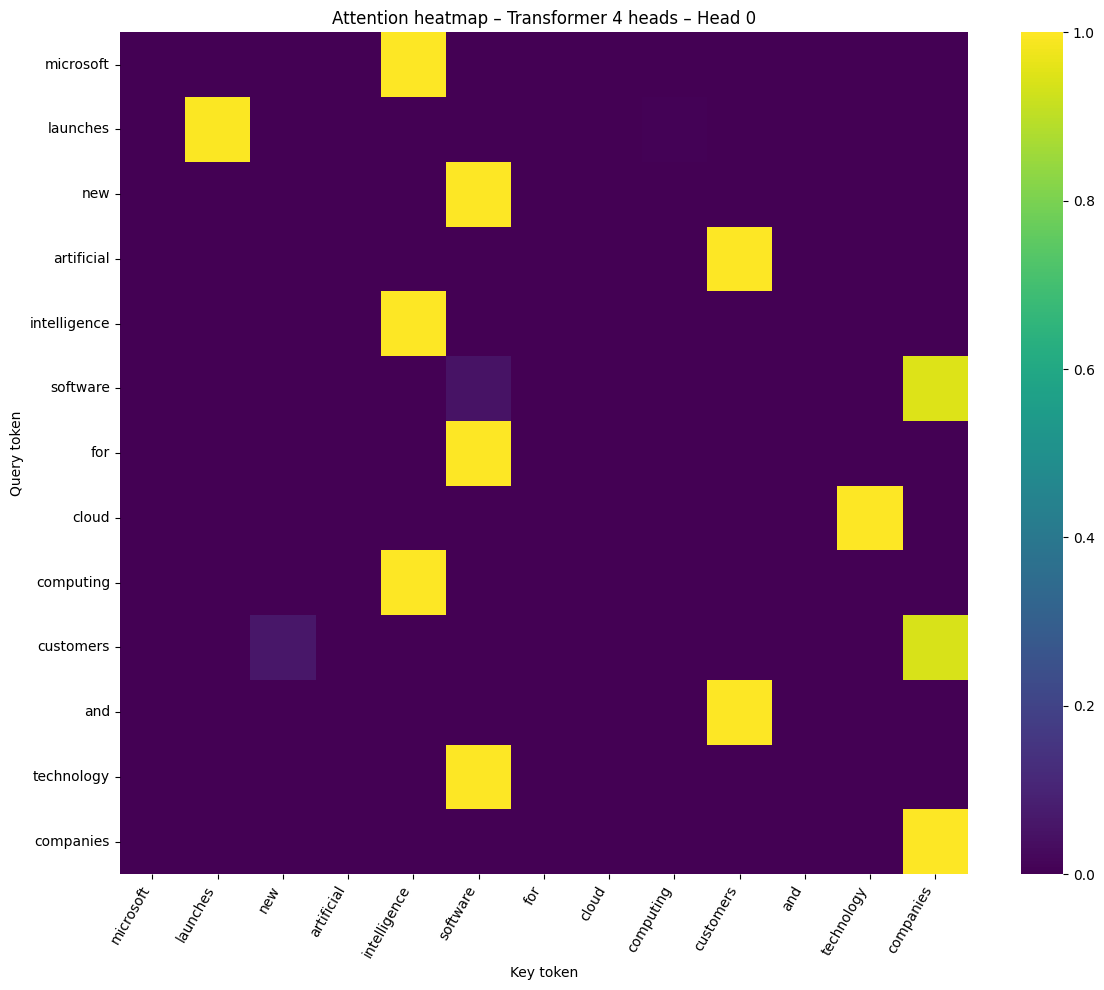

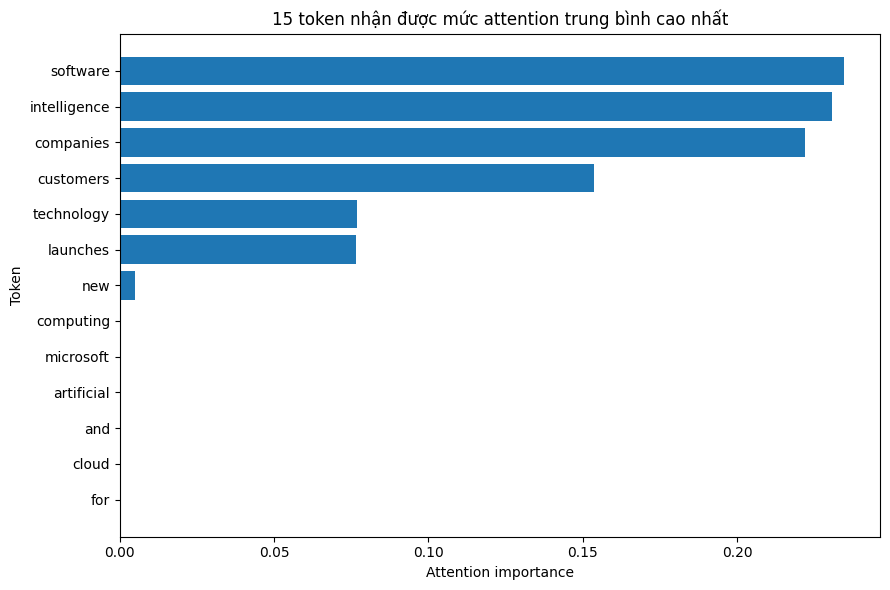

,Token,Attention importance
0,software,0.2346
1,intelligence,0.2308
2,companies,0.2220
3,customers,0.1538
4,technology,0.0770
5,launches,0.0766
6,new,0.0049
7,computing,0.0003
8,microsoft,0.0000
9,artificial,0.0000


In [ ]:
def prepare_single_text(text):
    """Mã hóa một văn bản và trả về tensor cùng danh sách token không padding."""
    encoded = encode_text(text)
    input_tensor = torch.tensor([encoded], dtype=torch.long, device=DEVICE)

    valid_ids = [token_id for token_id in encoded if token_id != PAD_ID]
    valid_tokens = [itos[token_id] for token_id in valid_ids]
    return input_tensor, valid_tokens


def visualize_attention(model, text, head_index=0):
    """Vẽ heatmap attention và biểu đồ token importance của một head."""
    model.eval()
    input_tensor, tokens = prepare_single_text(text)

    with torch.no_grad():
        logits, attention_layers = model(
            input_tensor,
            return_attention=True,
        )
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()

    predicted_label = int(np.argmax(probabilities))

    # Lấy encoder block cuối cùng, sample đầu tiên và head được chọn
    attention = attention_layers[-1][0, head_index].cpu().numpy()
    attention = attention[:len(tokens), :len(tokens)]

    print("Văn bản:", text)
    print("Dự đoán:", LABEL_NAMES[predicted_label])
    print("Xác suất:")
    for label, probability in zip(LABEL_NAMES, probabilities):
        print(f"  {label:9s}: {probability:.4f}")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        attention,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
    )
    plt.title(f"Attention heatmap – Transformer 4 heads – Head {head_index}")
    plt.xlabel("Key token")
    plt.ylabel("Query token")
    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Token importance = mức attention trung bình mà token nhận được từ mọi query
    token_importance = attention.mean(axis=0)
    importance_df = pd.DataFrame({
        "Token": tokens,
        "Attention importance": token_importance,
    }).sort_values("Attention importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(
        importance_df["Token"][::-1],
        importance_df["Attention importance"][::-1],
    )
    plt.title("15 token nhận được mức attention trung bình cao nhất")
    plt.xlabel("Attention importance")
    plt.ylabel("Token")
    plt.tight_layout()
    plt.show()

    return importance_df


attention_text = (
    "Microsoft launches new artificial intelligence software "
    "for cloud computing customers and technology companies"
)

attention_importance_df = visualize_attention(
    transformer_4h_model,
    attention_text,
    head_index=0,
)

display(attention_importance_df.reset_index(drop=True).round(4))

## 18. Dự đoán các câu tin tức mới

In [ ]:
def predict_news(model, text):
    """Dự đoán chủ đề và xác suất bốn lớp cho một văn bản mới."""
    model.eval()
    input_tensor, _ = prepare_single_text(text)

    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()

    predicted_index = int(np.argmax(probabilities))

    result = pd.DataFrame({
        "Class": LABEL_NAMES,
        "Probability": probabilities,
    }).sort_values("Probability", ascending=False)

    print("Văn bản:", text)
    print("Chủ đề dự đoán:", LABEL_NAMES[predicted_index])
    display(result.reset_index(drop=True).style.format({"Probability": "{:.4f}"}))


predict_news(
    transformer_4h_model,
    "NASA announces a new mission to explore Mars and study its atmosphere",
)

predict_news(
    transformer_4h_model,
    "The football team won the championship after scoring in the final minute",
)

Văn bản: NASA announces a new mission to explore Mars and study its atmosphere
Chủ đề dự đoán: Sci/Tech


,Class,Probability
0,Sci/Tech,0.9866
1,Business,0.0131
2,World,0.0003
3,Sports,0.0000


Văn bản: The football team won the championship after scoring in the final minute
Chủ đề dự đoán: Sports


,Class,Probability
0,Sports,0.9998
1,World,0.0002
2,Business,0.0000
3,Sci/Tech,0.0000


## 19. Nhận xét kết quả thực nghiệm tự động

Cell dưới đây lấy trực tiếp số liệu đã huấn luyện để tạo phần nhận xét có thể dùng trong báo cáo.

In [ ]:
# Xác định mô hình tốt nhất theo Macro F1
best_row = comparison_df.iloc[0]
fastest_row = comparison_df.sort_values("Training time (s)").iloc[0]

one_head_row = comparison_df[comparison_df["Model"] == "Transformer 1 head"].iloc[0]
four_head_row = comparison_df[comparison_df["Model"] == "Transformer 4 heads"].iloc[0]
bilstm_row = comparison_df[comparison_df["Model"] == "BiLSTM"].iloc[0]

head_f1_difference = four_head_row["Macro F1"] - one_head_row["Macro F1"]
transformer_vs_lstm = four_head_row["Macro F1"] - bilstm_row["Macro F1"]

print("NHẬN XÉT KẾT QUẢ")
print("-" * 72)
print(
    f"1. Mô hình có Macro F1 cao nhất là {best_row['Model']} "
    f"với Accuracy={best_row['Accuracy']:.4f} và Macro F1={best_row['Macro F1']:.4f}."
)
print(
    f"2. Mô hình huấn luyện nhanh nhất là {fastest_row['Model']} "
    f"với thời gian {fastest_row['Training time (s)']:.1f} giây."
)
print(
    f"3. Transformer 4 heads chênh {head_f1_difference:+.4f} Macro F1 "
    "so với Transformer 1 head trong cấu hình thực nghiệm này."
)
print(
    f"4. Transformer 4 heads chênh {transformer_vs_lstm:+.4f} Macro F1 "
    "so với BiLSTM."
)
print(
    "5. Attention heatmap cho phép quan sát trực tiếp cách mỗi token phân bổ "
    "sự chú ý đến các token khác, trong khi BiLSTM không cung cấp ma trận "
    "giải thích tương tự một cách trực tiếp."
)

NHẬN XÉT KẾT QUẢ
------------------------------------------------------------------------
1. Mô hình có Macro F1 cao nhất là Transformer 1 head với Accuracy=0.8796 và Macro F1=0.8790.
2. Mô hình huấn luyện nhanh nhất là Transformer 1 head với thời gian 23.6 giây.
3. Transformer 4 heads chênh -0.0070 Macro F1 so với Transformer 1 head trong cấu hình thực nghiệm này.
4. Transformer 4 heads chênh -0.0024 Macro F1 so với BiLSTM.
5. Attention heatmap cho phép quan sát trực tiếp cách mỗi token phân bổ sự chú ý đến các token khác, trong khi BiLSTM không cung cấp ma trận giải thích tương tự một cách trực tiếp.


## 20. Kết luận dùng cho báo cáo

- Notebook đã xây dựng thành công Transformer Encoder từ đầu, không sử dụng BERT hoặc Transformer pretrained.
- Cơ chế Scaled Dot-Product Attention được thể hiện bằng công thức, ví dụ số và mã nguồn cụ thể.
- Multi-Head Self-Attention được triển khai thông qua các phép chiếu Query, Key, Value, chia head, softmax và tổng hợp Value.
- Ba mô hình được huấn luyện trên cùng dữ liệu, cùng số epoch tối đa và được đánh giá trên toàn bộ test set chính thức.
- Kết quả thực tế được trình bày bằng bảng metric, learning curves, classification report, confusion matrix và thời gian huấn luyện.
- Attention heatmap hỗ trợ giải thích mô hình bằng cách chỉ ra quan hệ chú ý giữa các token.

### Hạn chế

- Thực nghiệm dùng 24.000 mẫu train để bảo đảm thời gian chạy hợp lý trên CPU; kết quả có thể cải thiện khi dùng toàn bộ dữ liệu.
- Tokenizer cấp từ đơn giản chưa xử lý tốt từ hiếm và biến thể từ như tokenizer subword.
- Mô hình chỉ có một encoder block và kích thước ẩn 64 nhằm cân bằng giữa hiệu quả và chi phí tính toán.

### Hướng phát triển

- Huấn luyện trên toàn bộ 108.000 mẫu train và 12.000 mẫu validation.
- So sánh 1, 2 và 3 encoder blocks.
- So sánh 1, 2, 4 và 8 attention heads.
- Thử tokenizer BPE hoặc WordPiece.
- So sánh Transformer tự xây dựng với DistilBERT hoặc BERT pretrained.

## 21. Lưu mô hình và kết quả

Cell này lưu trọng số Transformer 4 heads, vocabulary và bảng so sánh. Khi nộp chỉ notebook là đủ; các tệp dưới đây hữu ích nếu cần triển khai lại mô hình.

In [ ]:
OUTPUT_DIR = DATA_DIR / "ag_news_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Chuyển model về CPU trước khi lưu để tệp có thể nạp trên mọi máy
model_save_path = OUTPUT_DIR / "transformer_4heads_ag_news.pt"
vocab_save_path = OUTPUT_DIR / "vocabulary.txt"
results_save_path = OUTPUT_DIR / "model_comparison.csv"

torch.save(
    {
        "model_state_dict": transformer_4h_model.cpu().state_dict(),
        "model_config": MODEL_CONFIG,
        "num_heads": 4,
        "max_length": MAX_LENGTH,
        "label_names": LABEL_NAMES,
    },
    model_save_path,
)

with open(vocab_save_path, "w", encoding="utf-8") as file:
    for token in itos:
        file.write(token + "\n")

comparison_df.to_csv(results_save_path, index=False)

# Đưa model trở lại thiết bị hiện tại để vẫn dùng được trong notebook
transformer_4h_model.to(DEVICE)

print("Đã lưu model     :", model_save_path)
print("Đã lưu vocabulary:", vocab_save_path)
print("Đã lưu kết quả   :", results_save_path)

Đã lưu model     : /content/ag_news_data/ag_news_outputs/transformer_4heads_ag_news.pt
Đã lưu vocabulary: /content/ag_news_data/ag_news_outputs/vocabulary.txt
Đã lưu kết quả   : /content/ag_news_data/ag_news_outputs/model_comparison.csv
